# 🌐 Notebook 4: Distributed Limits & Good-Citizen Clients

Real services run on **many servers behind a load balancer**. An
in-memory limiter on each server is *per-server*, so the total allowed
rate is `N_servers × limit`. That's rarely what you want.

We'll cover two production topics:

1. **Server side** — how a shared counter (usually **Redis**) makes the
   limit global across servers.
2. **Client side** — how a *well-behaved* client reacts to `429` with
   **exponential backoff + jitter** (critical to avoid the "thundering
   herd" retry storm).

The notebook runs entirely in-memory (no Redis needed) using a fake
shared store, so the concepts are the focus.


## 🛠️ Setup

```bash
cd 04-patterns/rate-limiting-and-throttling
uv sync
```

Select the `.venv` kernel in VS Code (top-right of the notebook). If it doesn't appear, reload the window: `Cmd+Shift+P` → **Reload Window**.


## ❌ Bad: each server has its own limiter

If 3 servers each enforce "100 req/sec", clients actually get 300 req/sec
total — and the number silently changes when you scale up or down. Not fun
to reason about.


In [1]:
import time, random, threading
from collections import defaultdict, deque

class LocalLimiter:
    def __init__(self, limit, window):
        self.limit = limit; self.window = window
        self.events = defaultdict(deque)
    def allow(self, key):
        now = time.monotonic()
        q = self.events[key]
        while q and q[0] < now - self.window: q.popleft()
        if len(q) < self.limit:
            q.append(now); return True
        return False

# pretend 3 independent servers, each with its own 10/s limiter
servers = [LocalLimiter(10, 1.0) for _ in range(3)]
ok = 0
for _ in range(60):                         # 60 requests in one second
    s = random.choice(servers)              # load balancer picks one
    if s.allow('alice'): ok += 1
print(f"alice got {ok} allowed in 1s — intended limit was 10/s, actually ~30/s")

alice got 30 allowed in 1s — intended limit was 10/s, actually ~30/s


## ✅ Better: one shared store (Redis-style)

All servers ask **one shared counter** before serving. Below we simulate
Redis with a plain dict + a lock. In production this would be:
```python
# pipe = redis.pipeline()
# pipe.zremrangebyscore(key, 0, now - window)
# pipe.zadd(key, {now: now})
# pipe.zcard(key)
# pipe.expire(key, window)
# _, _, count, _ = pipe.execute()
# allow = count <= limit
```


In [2]:
class SharedStore:
    """Fake Redis: thread-safe dict of sorted sets."""
    def __init__(self):
        self._data = defaultdict(list)
        self._lock = threading.Lock()

    def add_and_count(self, key, now, window):
        with self._lock:
            arr = self._data[key]
            cutoff = now - window
            # drop old
            i = 0
            while i < len(arr) and arr[i] < cutoff: i += 1
            if i: del arr[:i]
            arr.append(now)
            return len(arr)

class DistributedLimiter:
    def __init__(self, store, limit, window):
        self.store = store; self.limit = limit; self.window = window
    def allow(self, key):
        count = self.store.add_and_count(key, time.monotonic(), self.window)
        return count <= self.limit

store = SharedStore()
servers = [DistributedLimiter(store, limit=10, window=1.0) for _ in range(3)]

ok = 0
for _ in range(60):
    s = random.choice(servers)
    if s.allow('alice'): ok += 1
print(f"alice got {ok} allowed in 1s with shared store — now matches limit")

alice got 10 allowed in 1s with shared store — now matches limit


## 🧑‍💻 Being a good-citizen client

When the server replies `429 Too Many Requests`, the **wrong** reaction is:
```
while not ok: retry_immediately()
```
Every client does that simultaneously → the server gets a bigger spike the
moment it recovers. This is called a **thundering herd**.

The right reaction is **exponential backoff + jitter**:
- wait `base * 2^attempt` seconds, but
- add a random offset so clients don't all retry in lock-step.

AWS's canonical paper: *"Exponential Backoff and Jitter"* recommends
**"full jitter"** — `sleep = random(0, base * 2^attempt)`.


In [3]:
import random

def call_with_backoff(do_call, max_attempts=6, base=0.1, cap=5.0):
    """do_call() returns (ok: bool, retry_after: float|None)."""
    for attempt in range(max_attempts):
        ok, retry_after = do_call()
        if ok:
            return True, attempt
        if retry_after is not None:
            # Server told us how long to wait — respect it.
            time.sleep(retry_after)
        else:
            # Full jitter: uniform in [0, min(cap, base * 2**attempt)]
            wait = random.uniform(0, min(cap, base * (2 ** attempt)))
            time.sleep(wait)
    return False, max_attempts

# Fake server: fails for first 3 calls, then succeeds.
calls = {'n': 0}
def flaky():
    calls['n'] += 1
    if calls['n'] <= 3:
        return False, 0.05   # 429 with Retry-After: 50ms
    return True, None

ok, attempts = call_with_backoff(flaky)
print(f"success={ok} after {attempts+1} attempts")

success=True after 4 attempts


## 💥 Why jitter matters (mini simulation)

Imagine 500 clients all hit a rate-limited endpoint at `t=0` and all get
`429`. If they **all** retry at `t=1s`, you get another 500-request spike.
With jitter, retries *spread out* across the interval.


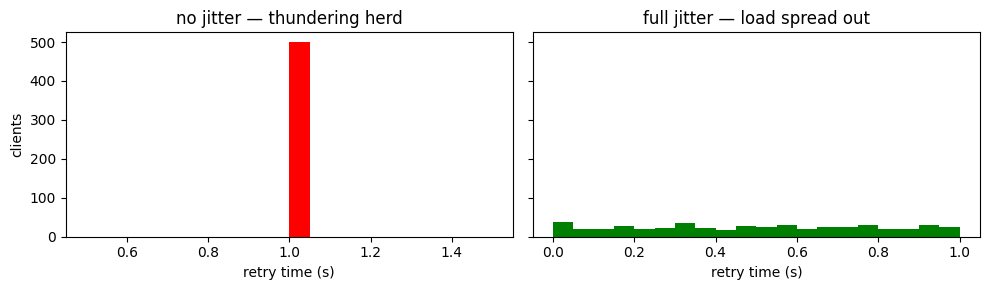

In [4]:
import matplotlib.pyplot as plt

def synchronized_retry_times(n=500, base=1.0):
    return [base] * n   # everyone waits exactly base seconds

def jittered_retry_times(n=500, base=1.0):
    return [random.uniform(0, base) for _ in range(n)]

sync_t = synchronized_retry_times()
jit_t  = jittered_retry_times()

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(sync_t, bins=20, color='red')
axes[0].set_title('no jitter — thundering herd')
axes[0].set_xlabel('retry time (s)'); axes[0].set_ylabel('clients')
axes[1].hist(jit_t, bins=20, color='green')
axes[1].set_title('full jitter — load spread out')
axes[1].set_xlabel('retry time (s)')
plt.tight_layout(); plt.show()

## 🧠 Takeaways

- **Per-server limits lie.** For a global rate, use a shared store (Redis).
- **Tell clients what to do.** Return `429` + `Retry-After` + the
  `X-RateLimit-*` headers. It's a contract, not a suggestion.
- **Respect `Retry-After`** on the client; if it's absent, use exponential
  backoff with **full jitter**.
- **Cap retries.** After `max_attempts`, surface a real error to the user.

### Further reading
- AWS blog — *"Exponential Backoff And Jitter"*
- Cloudflare — *"How we built rate limiting capable of scaling to millions of domains"*
- GitHub REST API — *"Resources in the REST API > Rate limiting"* (headers)
- Stripe API docs — *"Rate limits"* (token bucket + 429 behavior)
